# Import

In [1]:
%pip install -q "synthefy-nori[eval,interpretability]" xgboost scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 561.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.2/493.2 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 24.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages t

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.base import clone
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
)

from xgboost import XGBRegressor
from synthefy_nori import NoriRegressor


RANDOM_STATE = 42

nori_100m_path = "/content/drive/MyDrive/Colab Notebooks/nori/nori-100m.pt"
nori_6m_path = "/content/drive/MyDrive/Colab Notebooks/nori/nori-6m.pt"


# Select available device
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using device: {device}")

if device == "cuda":
    print(torch.cuda.get_device_name(0))

Using device: cuda
NVIDIA L4


In [4]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/nori/california_housing.csv')
data.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
X, y = data.drop(columns = 'MedHouseVal'), data['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_ctx = X_train.sample(n=2000, random_state=RANDOM_STATE)
y_ctx = y_train.loc[X_ctx.index]

X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


In [11]:

models = {
    "Nori": NoriRegressor(model='nori-100m',
                          model_path=nori_100m_path,
                          device="cuda")
}

results = {}

for name, model in models.items():
    # For Nori, fit only caches X_ctx/y_ctx; it does not update model weights.
    model.fit(
        X_ctx.iloc[:100].values,
        y_ctx.iloc[:100].values
    )

    # Time prediction only
    start_time = time.perf_counter()

    pred = model.predict(X_test[:2].values)

    end_time = time.perf_counter()
    prediction_time = end_time - start_time

    print(f"{name} prediction time: {prediction_time:.4f} seconds")

    results[name] = {
        "R2": r2_score(y_test[:2], pred),
        "MAE": mean_absolute_error(y_test[:2], pred),
        "Prediction Time (s)": prediction_time,
    }

pd.DataFrame(results).T.sort_values("R2", ascending=False)

Nori prediction time: 4.9435 seconds


,R2,MAE,Prediction Time (s)
Nori,-5798.696258,0.588658,4.943544


# xgboost baseline

In [18]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=1,        # avoid multiple processes competing for the same GPU
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.8}

Best CV MAE:
0.2929587459659052


In [19]:
best_xgb = grid_search.best_estimator_
print("Best model from GridSearchCV:")
print(best_xgb)

Best model from GridSearchCV:
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)


In [20]:

# clone() keeps the same hyperparameters but removes the fitted state
final_xgb = clone(best_xgb)
start_time = time.perf_counter()
final_xgb.fit(X_train, y_train)
end_time = time.perf_counter()
training_time = end_time - start_time
print(f"\nXGBoost training time: {training_time:.4f} seconds")


start_time = time.perf_counter()
pred = final_xgb.predict(X_test)
end_time = time.perf_counter()
prediction_time = end_time - start_time
print(f"XGBoost prediction time: {prediction_time:.4f} seconds")



r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
print(f"Test R2:  {r2:.4f}")
print(f"Test MAE: {mae:.4f}")


results = {}
results["XGBoost"] = {
    "R2": r2,
    "MAE": mae,
    "Training Time (s)": training_time,
    "Prediction Time (s)": prediction_time
}

results_df = pd.DataFrame(results).T

results_df


XGBoost training time: 2.1369 seconds
XGBoost prediction time: 0.0457 seconds
Test R2:  0.8537
Test MAE: 0.2832


,R2,MAE,Training Time (s),Prediction Time (s)
XGBoost,0.853716,0.283208,2.136905,0.045718


# nori-6m

In [27]:
# --------------------------------------------------
# Nori-6M: test different context sizes
# --------------------------------------------------

context_sizes = [100, 200, 500, 1000, 2000, 4000]

# Sample one fixed maximum context set
X_ctx = X_train.sample(n=4000, random_state=RANDOM_STATE)
y_ctx = y_train.loc[X_ctx.index]

results = []


for n_ctx in context_sizes:

    print(f"\n{'='*50}")
    print(f"Context size: {n_ctx}")
    print(f"{'='*50}")

    # Fresh Nori model for each experiment
    model = NoriRegressor(
        model="nori-6m",
        model_path=nori_6m_path,
        device="cuda"
    )

    # Select context subset
    X_ctx_n = X_ctx.iloc[:n_ctx]
    y_ctx_n = y_ctx.iloc[:n_ctx]

    # ------------------------------------------
    # Time fit/context loading
    # ------------------------------------------
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    model.fit(
        X_ctx_n.values,
        y_ctx_n.values
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    training_time = time.perf_counter() - start_time

    print(f"Fit time:        {training_time:.4f} seconds")


    # ------------------------------------------
    # Time prediction on FULL test set
    # ------------------------------------------
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    pred = model.predict(X_test.values)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    prediction_time = time.perf_counter() - start_time

    print(f"Prediction time: {prediction_time:.4f} seconds")


    # ------------------------------------------
    # Metrics on FULL test set
    # ------------------------------------------
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)

    print(f"R2:              {r2:.4f}")
    print(f"MAE:             {mae:.4f}")


    # ------------------------------------------
    # Save results
    # ------------------------------------------
    results.append({
        "Model": "Nori-6M",
        "Context Size": n_ctx,
        "R2": r2,
        "MAE": mae,
        "Training Time (s)": training_time,
        "Prediction Time (s)": prediction_time
    })


results_df = pd.DataFrame(results)

results_df


Context size: 100
Fit time:        0.0005 seconds
Prediction time: 2.7075 seconds
R2:              0.6603
MAE:             0.4769

Context size: 200
Fit time:        0.0003 seconds
Prediction time: 2.9951 seconds
R2:              0.7041
MAE:             0.4347

Context size: 500
Fit time:        0.0004 seconds
Prediction time: 2.9251 seconds
R2:              0.7711
MAE:             0.3696

Context size: 1000
Fit time:        0.0004 seconds
Prediction time: 4.1508 seconds
R2:              0.8047
MAE:             0.3371

Context size: 2000
Fit time:        0.0004 seconds
Prediction time: 4.6390 seconds
R2:              0.8237
MAE:             0.3088

Context size: 4000
Fit time:        0.0004 seconds
Prediction time: 7.2682 seconds
R2:              0.8452
MAE:             0.2850


,Model,Context Size,R2,MAE,Training Time (s),Prediction Time (s)
0,Nori-6M,100,0.660310,0.476891,0.000453,2.707533
1,Nori-6M,200,0.704078,0.434700,0.000259,2.995111
2,Nori-6M,500,0.771100,0.369622,0.000375,2.925136
3,Nori-6M,1000,0.804720,0.337125,0.000393,4.150849
4,Nori-6M,2000,0.823671,0.308786,0.000390,4.638967
5,Nori-6M,4000,0.845219,0.284991,0.000413,7.268154


In [12]:
def plot_nori_results(results_df, model_name="Nori"):
    fig, ax1 = plt.subplots(figsize=(6, 4))

    # R2 and MAE on left axis
    ax1.plot(
        results_df["Context Size"],
        results_df["R2"],
        marker="o",
        label="R2"
    )

    ax1.plot(
        results_df["Context Size"],
        results_df["MAE"],
        marker="o",
        label="MAE"
    )

    ax1.set_xlabel("Context Size")
    ax1.set_ylabel("R2 / MAE")
    ax1.grid(alpha=0.3)

    # Prediction time on right axis
    ax2 = ax1.twinx()

    ax2.plot(
        results_df["Context Size"],
        results_df["Prediction Time (s)"],
        marker="o",
        linestyle="--",
        label="Prediction Time"
    )

    ax2.set_ylabel("Prediction Time (s)")

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="best"
    )

    plt.title(f"{model_name}: Performance vs Context Size")
    plt.tight_layout()
    plt.show()

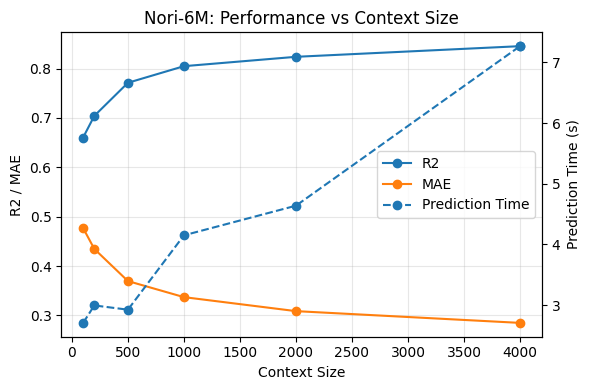

In [29]:


plot_nori_results(results_df, "Nori-6M")

In [30]:
results_df.to_excel(
    "/content/drive/MyDrive/Colab Notebooks/nori/nori_6m_results.xlsx",
    index=False
)

# nori-100M

In [7]:
X_ctx = X_train.sample(n=4000, random_state=RANDOM_STATE)
y_ctx = y_train.loc[X_ctx.index]

In [32]:
# --------------------------------------------------
# Nori-100M: test different context sizes
# --------------------------------------------------

# context_sizes = [100, 200, 500, 1000, 2000, 4000]
context_sizes = [2000, 4000]

# Sample one fixed maximum context set, do not sample again, use the same sample from 6m
# X_ctx = X_train.sample(n=4000, random_state=RANDOM_STATE)
# y_ctx = y_train.loc[X_ctx.index]

results = []


for n_ctx in context_sizes:

    print(f"\n{'='*50}")
    print(f"Context size: {n_ctx}")
    print(f"{'='*50}")

    # Fresh Nori model for each experiment
    model = NoriRegressor(
        model="nori-100m",
        model_path=nori_100m_path,
        device="cuda",
        memory_policy="max_context"
    )

    # Select context subset
    X_ctx_n = X_ctx.iloc[:n_ctx]
    y_ctx_n = y_ctx.iloc[:n_ctx]

    # ------------------------------------------
    # Time fit/context loading
    # ------------------------------------------
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    model.fit(
        X_ctx_n.values,
        y_ctx_n.values
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    training_time = time.perf_counter() - start_time

    print(f"Fit time:        {training_time:.4f} seconds")


    # ------------------------------------------
    # Time prediction on FULL test set
    # ------------------------------------------
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    pred = model.predict(X_test.values)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    prediction_time = time.perf_counter() - start_time

    print(f"Prediction time: {prediction_time:.4f} seconds")


    # ------------------------------------------
    # Metrics on FULL test set
    # ------------------------------------------
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)

    print(f"R2:              {r2:.4f}")
    print(f"MAE:             {mae:.4f}")


    # ------------------------------------------
    # Save results
    # ------------------------------------------
    results.append({
        "Model": "Nori-100M",
        "Context Size": n_ctx,
        "R2": r2,
        "MAE": mae,
        "Training Time (s)": training_time,
        "Prediction Time (s)": prediction_time
    })


results_df = pd.DataFrame(results)

results_df


Context size: 2000
Fit time:        0.0006 seconds


OutOfMemoryError: CUDA out of memory. Tried to allocate 5.91 GiB. GPU 0 has a total capacity of 14.56 GiB of which 4.82 GiB is free. Including non-PyTorch memory, this process has 9.74 GiB memory in use. Of the allocated memory 9.25 GiB is allocated by PyTorch, and 329.35 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [8]:
import gc

# --------------------------------------------------
# Nori-100M: test different context sizes
# --------------------------------------------------

context_sizes = [4000]
batch_size = 100

# Reuse the same context data from Nori-6M
assert len(X_ctx) >= max(context_sizes)

results_100m = []

for n_ctx in context_sizes:

    print(f"\n{'='*50}")
    print(f"Context size: {n_ctx}")
    print(f"{'='*50}")

    # Clean up GPU memory before loading a new model
    gc.collect()
    torch.cuda.empty_cache()

    # Fresh Nori model for each experiment
    model = NoriRegressor(
        model="nori-100m",
        model_path=nori_100m_path,
        device="cuda",
        memory_policy="max_context"
    )

    # Select context subset
    X_ctx_n = X_ctx.iloc[:n_ctx]
    y_ctx_n = y_ctx.iloc[:n_ctx]

    # ------------------------------------------
    # Time fit/context loading
    # ------------------------------------------
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    model.fit(
        X_ctx_n.values,
        y_ctx_n.values
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    training_time = time.perf_counter() - start_time

    print(f"Fit time: {training_time:.4f} seconds")

    # ------------------------------------------
    # Time prediction on FULL test set in batches
    # ------------------------------------------

    predictions = []

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    for i in range(0, len(X_test), batch_size):

        # Select the current batch
        X_batch = X_test.iloc[i:i + batch_size].values

        # Predict this batch
        batch_pred = model.predict(X_batch)

        # Store predictions
        predictions.append(
            np.asarray(batch_pred).reshape(-1)
        )

        # Print progress
        print(
            f"Predicted {min(i + batch_size, len(X_test))}"
            f"/{len(X_test)} samples"
        )

    # Combine all batch predictions
    pred = np.concatenate(predictions)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    prediction_time = time.perf_counter() - start_time

    print(f"\nPrediction time: {prediction_time:.4f} seconds")

    # ------------------------------------------
    # Metrics on FULL test set
    # ------------------------------------------

    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)

    print(f"R2:  {r2:.4f}")
    print(f"MAE: {mae:.4f}")

    # ------------------------------------------
    # Save results
    # ------------------------------------------

    results_100m.append({
        "Model": "Nori-100M",
        "Context Size": n_ctx,
        "Batch Size": batch_size,
        "R2": r2,
        "MAE": mae,
        "Training Time (s)": training_time,
        "Prediction Time (s)": prediction_time
    })

    # ------------------------------------------
    # Release memory before next experiment
    # ------------------------------------------

    del model, predictions, pred, batch_pred, X_batch

    gc.collect()
    torch.cuda.empty_cache()


# Convert results to DataFrame
results_100m_df = pd.DataFrame(results_100m)

results_100m_df


Context size: 4000
Fit time: 0.0009 seconds
Predicted 100/4128 samples
Predicted 200/4128 samples
Predicted 300/4128 samples
Predicted 400/4128 samples
Predicted 500/4128 samples
Predicted 600/4128 samples
Predicted 700/4128 samples
Predicted 800/4128 samples
Predicted 900/4128 samples
Predicted 1000/4128 samples
Predicted 1100/4128 samples
Predicted 1200/4128 samples
Predicted 1300/4128 samples
Predicted 1400/4128 samples
Predicted 1500/4128 samples
Predicted 1600/4128 samples
Predicted 1700/4128 samples
Predicted 1800/4128 samples
Predicted 1900/4128 samples
Predicted 2000/4128 samples
Predicted 2100/4128 samples
Predicted 2200/4128 samples
Predicted 2300/4128 samples
Predicted 2400/4128 samples
Predicted 2500/4128 samples
Predicted 2600/4128 samples
Predicted 2700/4128 samples
Predicted 2800/4128 samples
Predicted 2900/4128 samples
Predicted 3000/4128 samples
Predicted 3100/4128 samples
Predicted 3200/4128 samples
Predicted 3300/4128 samples
Predicted 3400/4128 samples
Predicted 35

,Model,Context Size,Batch Size,R2,MAE,Training Time (s),Prediction Time (s)
0,Nori-100M,4000,100,0.854449,0.274531,0.000877,747.058872


In [ ]:
data_100m = [
    [100, 0.6599, 0.4762, 0.0007, 24.6329],
    [200, 0.7179, 0.4213, 0.0003, 27.5836],
    [500, 0.7885, 0.3515, 0.0004, 43.0869],
    [1000, 0.8126, 0.3271, 0.0004, 72.0029],
    [2000, 0.8307, 0.2989, 0.0007, 2124.1896],
    [4000, 0.8544, 0.2745, 0.0009, 747.0589],
]

results_100m = []

for context_size, r2, mae, train_time, pred_time in data_100m:
    results_100m.append({
        "Model": "Nori-100M",
        "Context Size": context_size,
        "R2": r2,
        "MAE": mae,
        "Training Time (s)": train_time,
        "Prediction Time (s)": pred_time
    })

results_100m_df = pd.DataFrame(results_100m)

results_100m_df

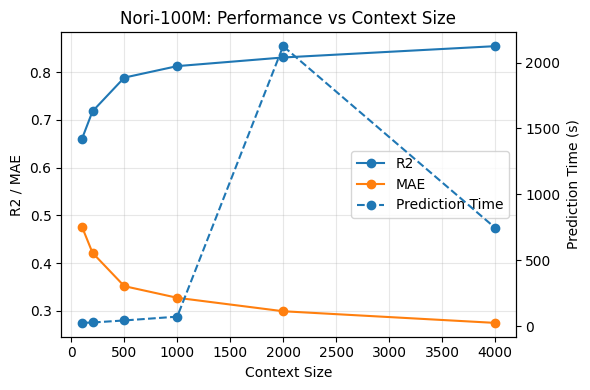

In [13]:
plot_nori_results(results_100m_df, "Nori-100M")

In [14]:
results_100m_df.to_excel(
    "/content/drive/MyDrive/Colab Notebooks/nori/nori_100m_results.xlsx",
    index=False
)

# combine output

In [ ]:
base_path = "/content/drive/MyDrive/Colab Notebooks/nori"

results_6m_df = pd.read_excel(f"{base_path}/nori_6m_results.xlsx")
results_100m_df = pd.read_excel(f"{base_path}/nori_100m_results.xlsx")

combined_results_df = pd.concat(
    [results_6m_df, results_100m_df],
    ignore_index=True
)

In [16]:
combined_results_df.sort_values(
    by=["MAE"],
    ascending=True,
)


,Model,Context Size,R2,MAE,Training Time (s),Prediction Time (s)
11,Nori-100M,4000,0.854400,0.274500,0.000900,747.058900
5,Nori-6M,4000,0.845219,0.284991,0.000413,7.268154
10,Nori-100M,2000,0.830700,0.298900,0.000700,2124.189600
4,Nori-6M,2000,0.823671,0.308786,0.000390,4.638967
9,Nori-100M,1000,0.812600,0.327100,0.000400,72.002900
3,Nori-6M,1000,0.804720,0.337125,0.000393,4.150849
8,Nori-100M,500,0.788500,0.351500,0.000400,43.086900
2,Nori-6M,500,0.771100,0.369622,0.000375,2.925136
7,Nori-100M,200,0.717900,0.421300,0.000300,27.583600
1,Nori-6M,200,0.704078,0.434700,0.000259,2.995111


# outlier detection

In [18]:
def true_function(u, v):
    return (
        10
        + 0.7 * u
        - 0.4 * v
        + 0.00005 * u**2
        + 0.00008 * v**2
        + 0.00003 * u * v
    )


rng = np.random.default_rng(RANDOM_STATE)

context_sizes = [100, 200, 500, 1000, 2000, 4000]
max_context = max(context_sizes)
n_test = 100


# Generate unique values for training + in-range testing
u_values = rng.choice(
    np.arange(0, 10001),
    size=max_context + n_test,
    replace=False
)

v_values = rng.choice(
    np.arange(0, 10001),
    size=max_context + n_test,
    replace=False
)


# -------------------------
# Training/context data
# 0 - 10,000
# -------------------------

X_train = pd.DataFrame({
    "u": u_values[:max_context],
    "v": v_values[:max_context]
})

y_train = true_function(
    X_train["u"].values,
    X_train["v"].values
)


# -------------------------
# In-range test data
# unseen values from 0 - 10,000
# -------------------------

X_test_in = pd.DataFrame({
    "u": u_values[max_context:],
    "v": v_values[max_context:]
})

y_test_in = true_function(
    X_test_in["u"].values,
    X_test_in["v"].values
)


# -------------------------
# Out-of-range test data
# 10,001 - 15,000
# -------------------------

X_test_out = pd.DataFrame({
    "u": rng.choice(
        np.arange(10001, 15001),
        size=n_test,
        replace=False
    ),
    "v": rng.choice(
        np.arange(10001, 15001),
        size=n_test,
        replace=False
    )
})

y_test_out = true_function(
    X_test_out["u"].values,
    X_test_out["v"].values
)

In [21]:
# --------------------------------------------------
# Nori-6M: synthetic function experiment
# --------------------------------------------------

results = []

for n_ctx in context_sizes:

    print(f"\n{'='*50}")
    print(f"Context size: {n_ctx}")
    print(f"{'='*50}")

    # Fresh model for each context size
    model = NoriRegressor(
        model="nori-6m",
        model_path=nori_6m_path,
        device="cuda"
    )

    # Use first n_ctx training/context samples
    X_train_n = X_train.iloc[:n_ctx]
    y_train_n = y_train[:n_ctx]

    # --------------------------------------------------
    # Fit / load context
    # --------------------------------------------------

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    model.fit(
        X_train_n.values,
        y_train_n
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    training_time = time.perf_counter() - start_time


    # --------------------------------------------------
    # Predict IN-RANGE test data
    # --------------------------------------------------

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    pred_in = model.predict(X_test_in.values)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    prediction_time_in = time.perf_counter() - start_time

    r2_in = r2_score(y_test_in, pred_in)
    mae_in = mean_absolute_error(y_test_in, pred_in)


    # --------------------------------------------------
    # Predict OUT-OF-RANGE test data
    # --------------------------------------------------

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    pred_out = model.predict(X_test_out.values)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    prediction_time_out = time.perf_counter() - start_time

    r2_out = r2_score(y_test_out, pred_out)
    mae_out = mean_absolute_error(y_test_out, pred_out)


    # --------------------------------------------------
    # Print results
    # --------------------------------------------------

    print(f"Fit time: {training_time:.4f} seconds")

    print("\nIn-range:")
    print(f"R2:              {r2_in:.4f}")
    print(f"MAE:             {mae_in:.4f}")
    print(f"Prediction time: {prediction_time_in:.4f} seconds")

    print("\nOut-of-range:")
    print(f"R2:              {r2_out:.4f}")
    print(f"MAE:             {mae_out:.4f}")
    print(f"Prediction time: {prediction_time_out:.4f} seconds")


    # --------------------------------------------------
    # Save results
    # --------------------------------------------------

    results.append({
        "Model": "Nori-6M",
        "Context Size": n_ctx,
        "In-Range R2": r2_in,
        "In-Range MAE": mae_in,
        "Out-of-Range R2": r2_out,
        "Out-of-Range MAE": mae_out,
        "Training Time (s)": training_time,
        "In-Range Prediction Time (s)": prediction_time_in,
        "Out-of-Range Prediction Time (s)": prediction_time_out
    })


results_df = pd.DataFrame(results)

results_df


Context size: 100
Fit time: 0.0007 seconds

In-range:
R2:              0.9997
MAE:             52.9156
Prediction time: 5.4242 seconds

Out-of-range:
R2:              -0.8965
MAE:             5241.9920
Prediction time: 0.3180 seconds

Context size: 200
Fit time: 0.0003 seconds

In-range:
R2:              0.9998
MAE:             42.4572
Prediction time: 0.5897 seconds

Out-of-range:
R2:              -1.3311
MAE:             5741.2866
Prediction time: 0.3275 seconds

Context size: 500
Fit time: 0.0003 seconds

In-range:
R2:              0.9999
MAE:             26.3853
Prediction time: 0.5804 seconds

Out-of-range:
R2:              -1.2100
MAE:             5533.5308
Prediction time: 0.3243 seconds

Context size: 1000
Fit time: 0.0003 seconds

In-range:
R2:              0.9999
MAE:             24.6382
Prediction time: 0.6097 seconds

Out-of-range:
R2:              -0.9280
MAE:             5052.5147
Prediction time: 0.3644 seconds

Context size: 2000
Fit time: 0.0003 seconds

In-range:
R2:

,Model,Context Size,In-Range R2,In-Range MAE,Out-of-Range R2,Out-of-Range MAE,Training Time (s),In-Range Prediction Time (s),Out-of-Range Prediction Time (s)
0,Nori-6M,100,0.999685,52.915633,-0.896479,5241.992040,0.000671,5.424198,0.317966
1,Nori-6M,200,0.999791,42.457234,-1.331113,5741.286565,0.000306,0.589689,0.327499
2,Nori-6M,500,0.999936,26.385325,-1.209957,5533.530775,0.000317,0.580402,0.324319
3,Nori-6M,1000,0.999941,24.638196,-0.927960,5052.514736,0.000299,0.609704,0.364414
4,Nori-6M,2000,0.999955,21.389085,-1.280947,5518.053533,0.000328,0.777041,0.530236
5,Nori-6M,4000,0.999960,20.353796,-1.467099,5748.562701,0.000347,1.218693,0.968832


,Value,Distance Outside Range,True,Predicted,Error,Absolute Error
0,10000.000000,0.000000,19010.000000,18873.196000,-136.804000,136.804000
1,10050.505051,50.505051,19187.175798,18926.374129,-260.801669,260.801669
2,10101.010101,101.010101,19365.167840,18996.236678,-368.931162,368.931162
3,10151.515152,151.515152,19543.976125,19062.185712,-481.790413,481.790413
4,10202.020202,202.020202,19723.600653,19146.841984,-576.758669,576.758669


Overall MAE: 6096.4398


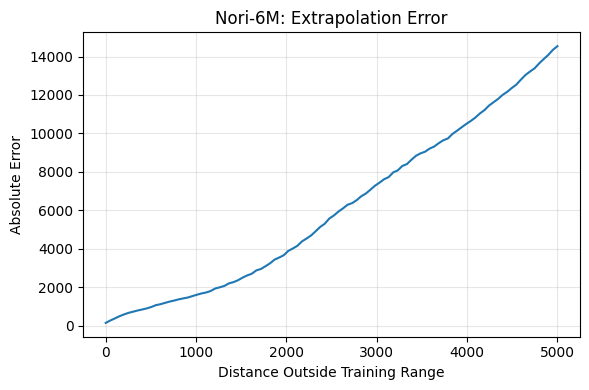

In [22]:
# --------------------------------------------------
# Extrapolation error by distance from training range
# --------------------------------------------------

# 100 evenly spaced values from 10,000 to 15,000
test_values = np.linspace(10000, 15000, 100)

X_extrapolation = pd.DataFrame({
    "u": test_values,
    "v": test_values
})

# True values
y_true = true_function(
    X_extrapolation["u"].values,
    X_extrapolation["v"].values
)

# Nori predictions
y_pred = model.predict(X_extrapolation.values)

# Point-by-point errors
error = y_pred - y_true
absolute_error = np.abs(error)

# Distance outside training range
distance = test_values - 10000


# Save everything in a DataFrame
error_df = pd.DataFrame({
    "Value": test_values,
    "Distance Outside Range": distance,
    "True": y_true,
    "Predicted": y_pred,
    "Error": error,
    "Absolute Error": absolute_error
})

display(error_df.head())


# Overall MAE
print(f"Overall MAE: {absolute_error.mean():.4f}")


# --------------------------------------------------
# Plot error progression
# --------------------------------------------------

plt.figure(figsize=(6, 4))

plt.plot(
    error_df["Distance Outside Range"],
    error_df["Absolute Error"]
)

plt.xlabel("Distance Outside Training Range")
plt.ylabel("Absolute Error")
plt.title("Nori-6M: Extrapolation Error")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()